### Imports

In [23]:
import pandas as pd
import xlwings as xw
import numpy as np
from DENTON import *
from DENTON import _calc_gamma

In [24]:
wb = xw.apps.active.books.active

In [25]:
sh_results = wb.sheets['results'].range("B2").options(pd.DataFrame, index=False, header=1, expand='table').value
sh_nodes = wb.sheets['nodes'].range("A1").options(pd.DataFrame, index=False, header=1, expand='table').value
sh_elements = wb.sheets['elements'].range("A1").options(pd.DataFrame, index=False, header=1, expand='table').value
sh_charts = wb.sheets['charts']
sh_WA = wb.sheets['W&A_results']

In [26]:
results = results_to_dataframe(sh_results)
nodes = nodes_to_dataframe(sh_nodes)
elements = elements_to_dataframe(sh_elements)
# results.loc[results['Elem'] == 1117].loc[lambda x: x['Load'] == 'C1_P+ALL+45HB(max)']

### Averaging the forces in the nodes

In [27]:
mean_forces = results.groupby(['Load', 'Node'])[['mxx', 'myy', 'mxy']].mean()#.reset_index()
results_mean = results[['Elem', 'Load', 'Node']].merge(mean_forces,'left',on=['Load', 'Node'])
# results_mean.loc[results_mean['Elem'] == 1117].loc[lambda x: x['Load'] == 'C1_P+ALL+45HB(max)']

### Denton capacity

In [28]:
capacity = [[1345.2, 0], [252.4, 80]]

MR = create_moment_field(
    capacity_to_triad(
        capacity))

### Results table updated with the 'gamma' and nodes coordinates

In [29]:
results_mean['gamma'] = (results_mean.apply(lambda r: _calc_gamma(r, MR=MR),axis=1))
results_mean = results_mean.merge(nodes[['Node', 'x', 'y']], 'left', on='Node')

In [30]:
DENTON_summary = pd.DataFrame(results_mean.groupby('Load')['gamma'].min().round(3).reset_index())
DENTON_summary

,Load,gamma
0,C1_P,3.037
1,C1_P+ALL(max),1.962
2,C1_P+ALL+45HB(max),1.464
3,C1_P+ALL+SV100(max),1.558
4,C1_P+ALL+SV150(max),1.555
5,C1_P+ALL+SV196(max),1.491
6,C1_P+ALL+SV80(max),1.678
7,C1_P+ALL+SVTT(max),1.755


### Excel export

In [31]:
wb.sheets['results'].range('S2').value = 'γ'
wb.sheets['results'].range('S3').options(transpose=True).value = results_mean['gamma'].values
wb.sheets['results'].range('U2').value = DENTON_summary

In [21]:
loads = results['Load'].unique().tolist()
loads

['C1_P+ALL(max)',
 'C1_P+ALL+SV80(max)',
 'C1_P+ALL+SV100(max)',
 'C1_P+ALL+SV150(max)',
 'C1_P+ALL+SV196(max)',
 'C1_P+ALL+SVTT(max)',
 'C1_P+ALL+45HB(max)',
 'C1_P']

In [22]:
def plot_export_to_excel(loads: list, sh):
    top = 0  # piksele od góry arkusza
    left = 0 # piksele od lewej krawędzi
    gap_y = 0  # odstęp pionowy między obrazami

    for load in loads:
        x = results_mean[results_mean['Load'] == load]['x'].to_numpy(dtype=float)
        y = results_mean[results_mean['Load'] == load]['y'].to_numpy(dtype=float)
        z = results_mean[results_mean['Load'] == load]['gamma'].to_numpy(dtype=float)
        fig = contour_plot(x,y,z, cmax=2, title=load)
        
        pic = sh.pictures.add(
            fig,
            name=f'cntr_{load}',
            update=True,
            left=left,
            top=top
        )
            
        # Opcjonalnie: ustaw z góry docelowe wymiary (w pikselach)
        pic.height = 360
        pic.width = 480

        # Przesuń pionową pozycję dla kolejnego wykresu
        top += pic.height + gap_y

plot_export_to_excel(loads= loads[:7], sh= sh_charts)

# Wood & Armer

In [15]:
cap_long = 1345.2
cap_trans = 252.4

WA_results: pd.DataFrame = sh_WA.range("B2").options(pd.DataFrame, expand='table', header=1, index=False).value
WA_results = WA_results.loc[:, ['Elem', 'Load', 'Node', 'W-A Moment Bot Dir. 1 (kN·m/m)', 'W-A Moment Bot Dir. 2 (kN·m/m)']]
WA_results.rename(columns={
    'W-A Moment Bot Dir. 1 (kN·m/m)': 'dir1',
    'W-A Moment Bot Dir. 2 (kN·m/m)': 'dir2'
}, inplace=True)
WA_results['Elem'] = WA_results['Elem'].astype(int)
WA_results['Node'] = WA_results['Node'].astype(int)
WA_results.head(2)

,Elem,Load,Node,dir1,dir2
0,623,C1_P+ALL(max),13,1.136,41.748
1,623,C1_P+ALL(max),491,193.908,66.605


In [16]:
WA_results = WA_results.groupby(['Load', 'Node'])[['dir1', 'dir2']].mean().reset_index()
WA_results.head(2)

,Load,Node,dir1,dir2
0,C1_P,1,1.359,0.38
1,C1_P,2,0.000,0.00


In [17]:
WA_results['dir1'] = WA_results['dir1'].apply(lambda x: cap_long / x if x != 0 else 99)
WA_results['dir2'] = WA_results['dir2'].apply(lambda x: cap_trans / x if x != 0 else 99)
WA_results = WA_results.merge(nodes, 'left', on='Node').drop('z', axis=1)
WA_results.head(2)

,Load,Node,dir1,dir2,x,y
0,C1_P,1,989.845475,664.210526,0.00000,0.000000
1,C1_P,2,99.000000,99.000000,0.07498,0.555597


In [18]:
loads = WA_results['Load'].unique().tolist()
loads

['C1_P',
 'C1_P+ALL(max)',
 'C1_P+ALL+45HB(max)',
 'C1_P+ALL+SV100(max)',
 'C1_P+ALL+SV150(max)',
 'C1_P+ALL+SV196(max)',
 'C1_P+ALL+SV80(max)',
 'C1_P+ALL+SVTT(max)']

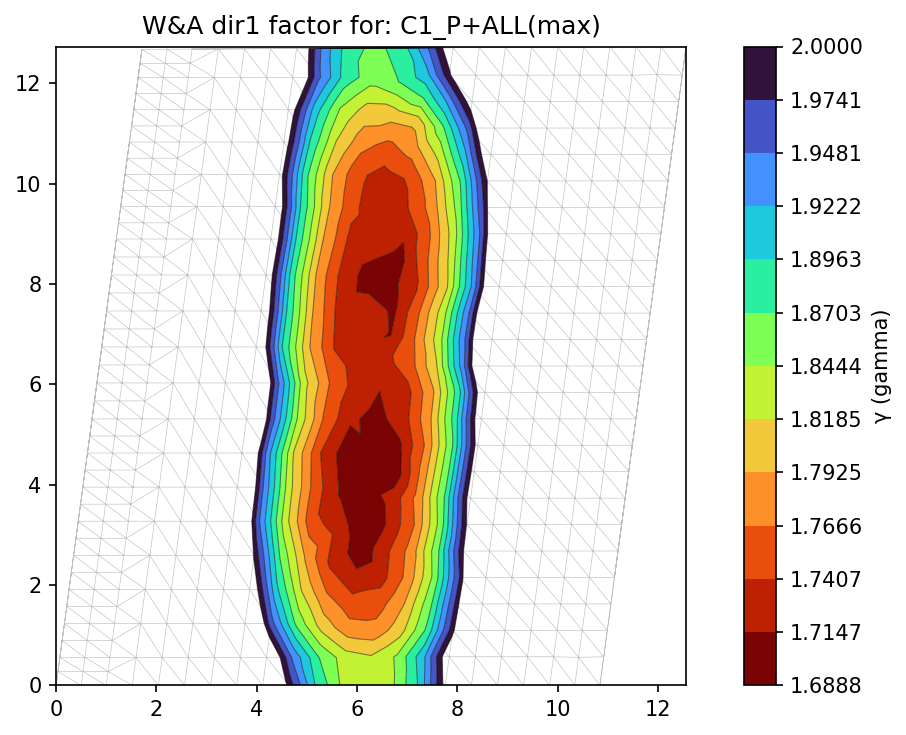

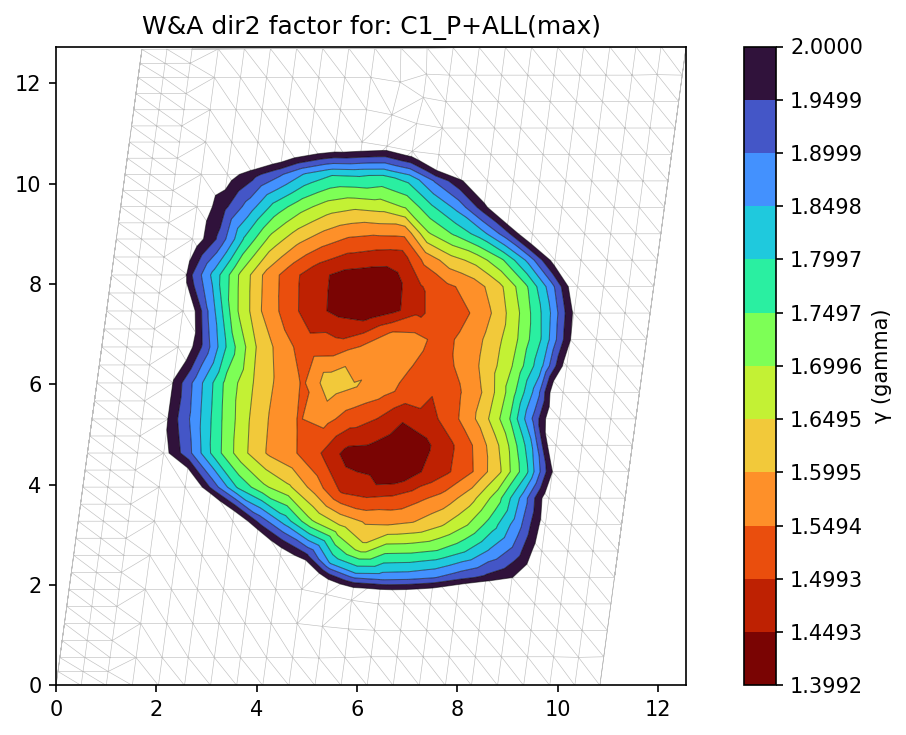

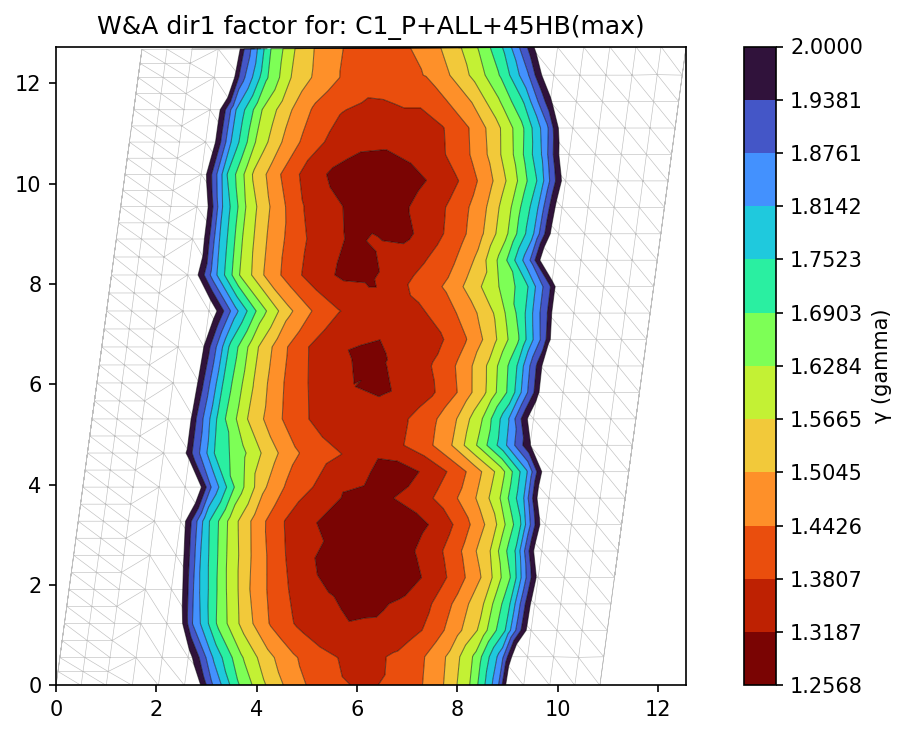

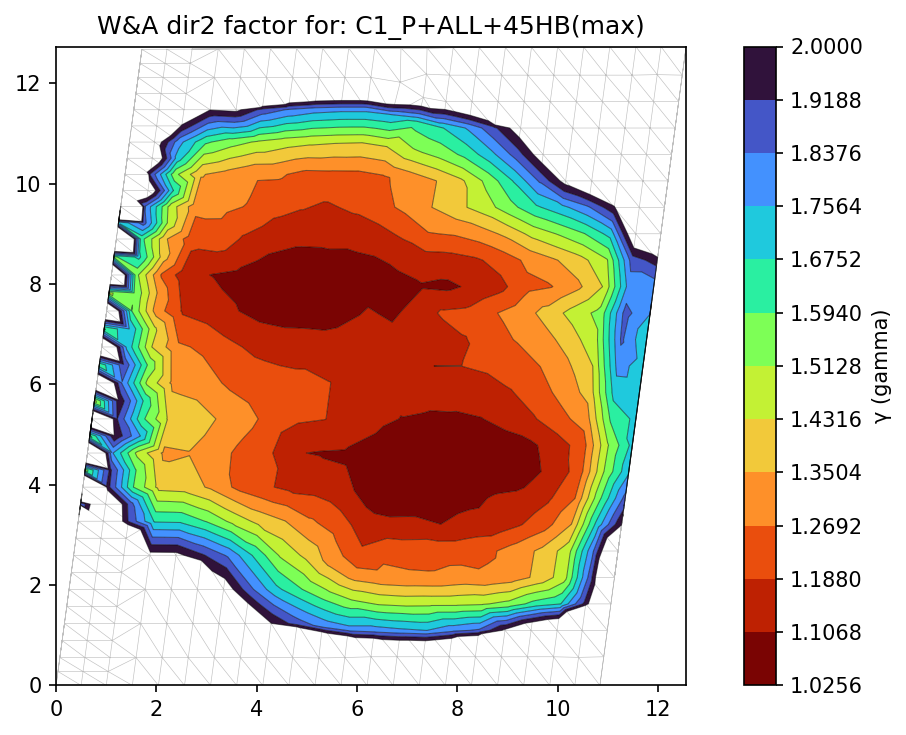

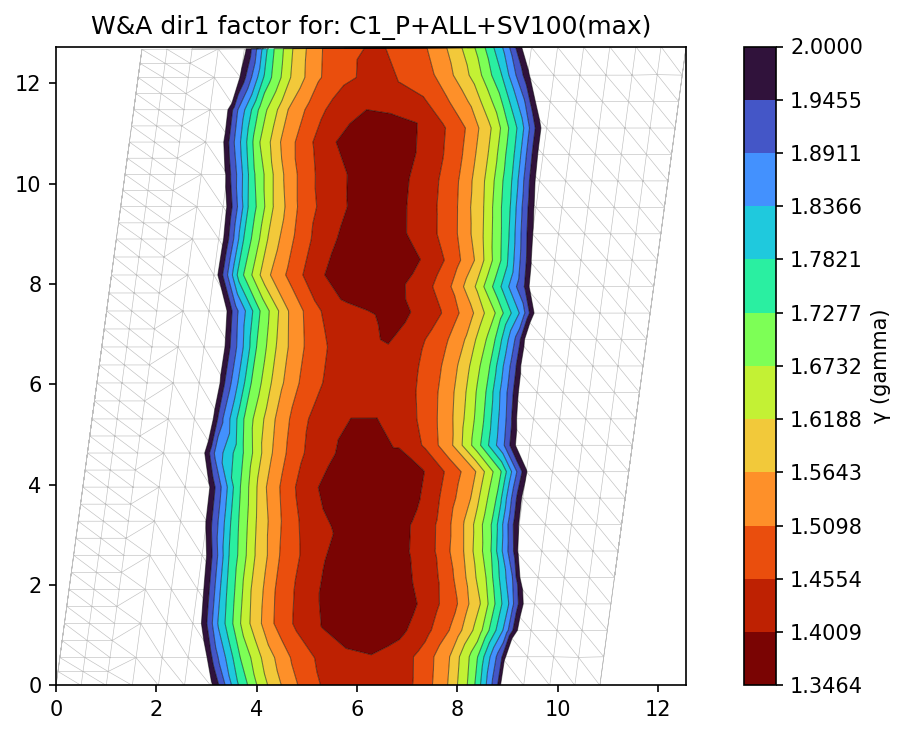

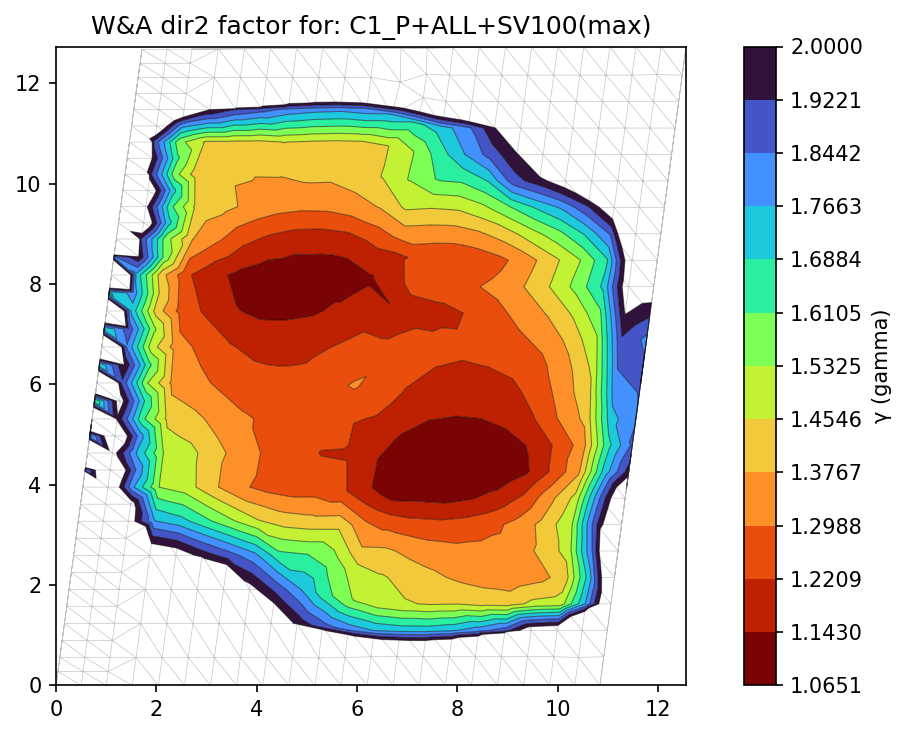

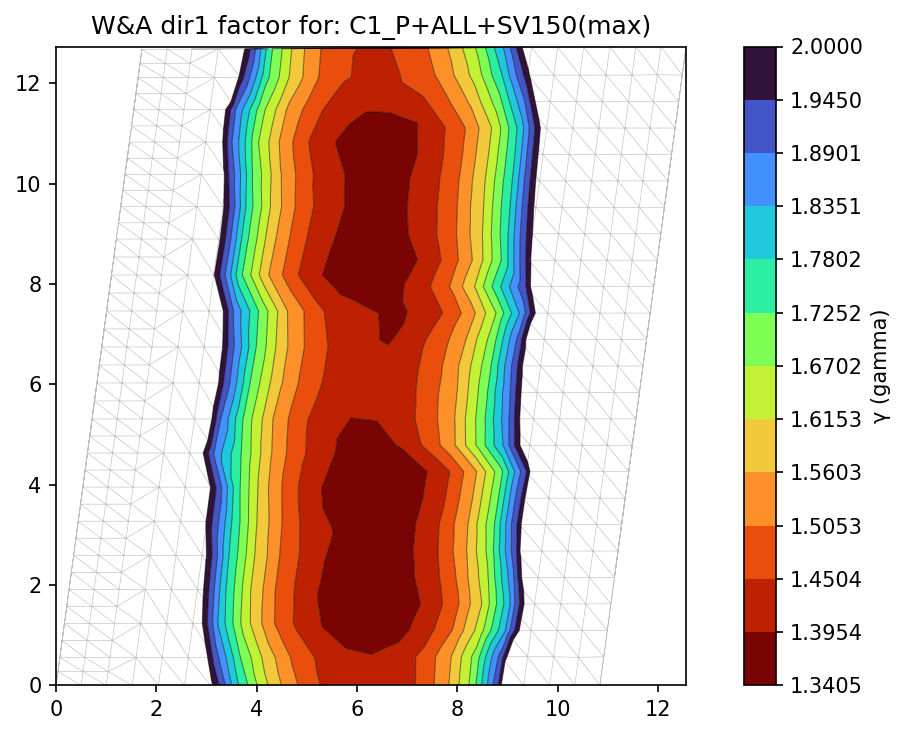

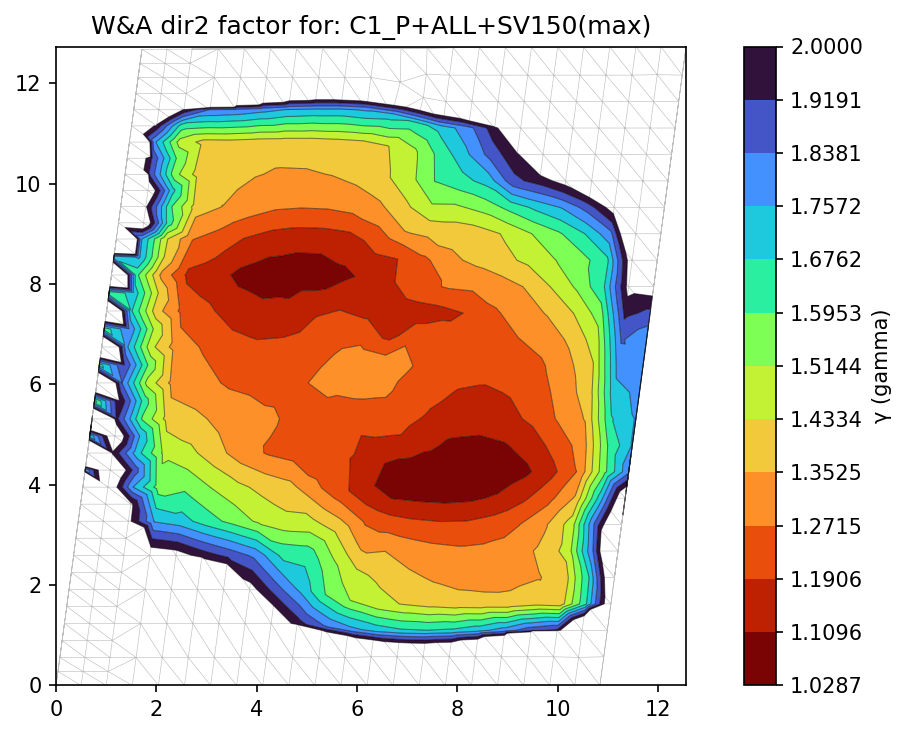

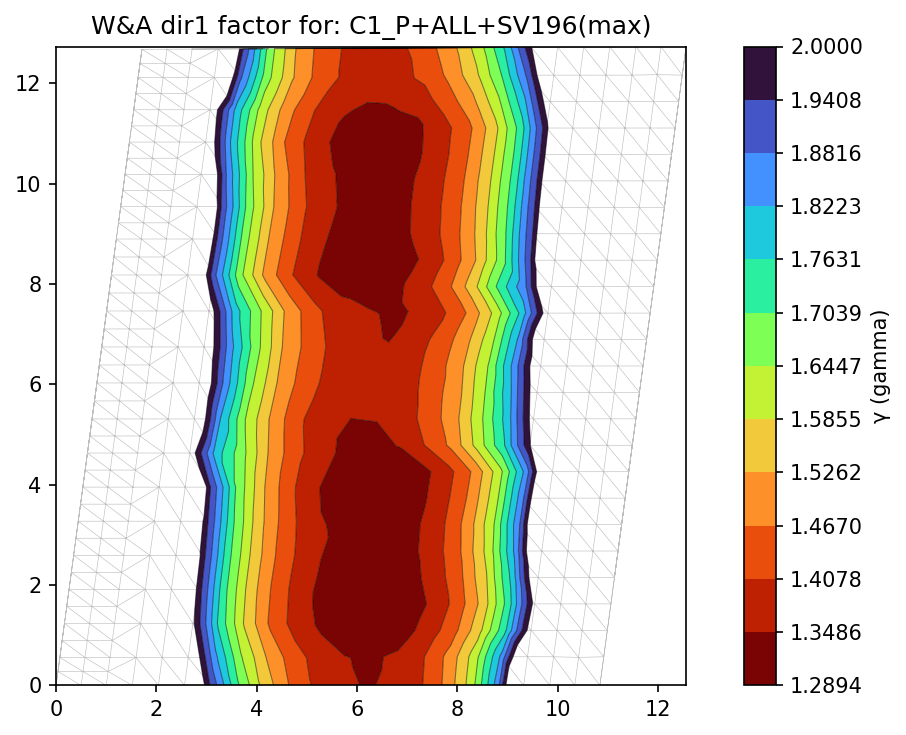

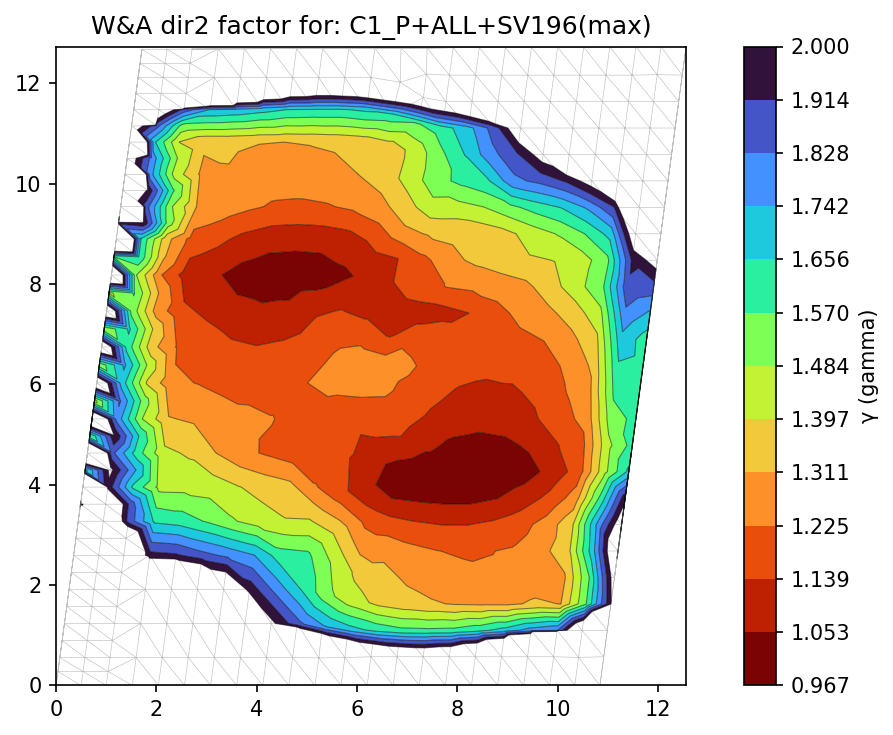

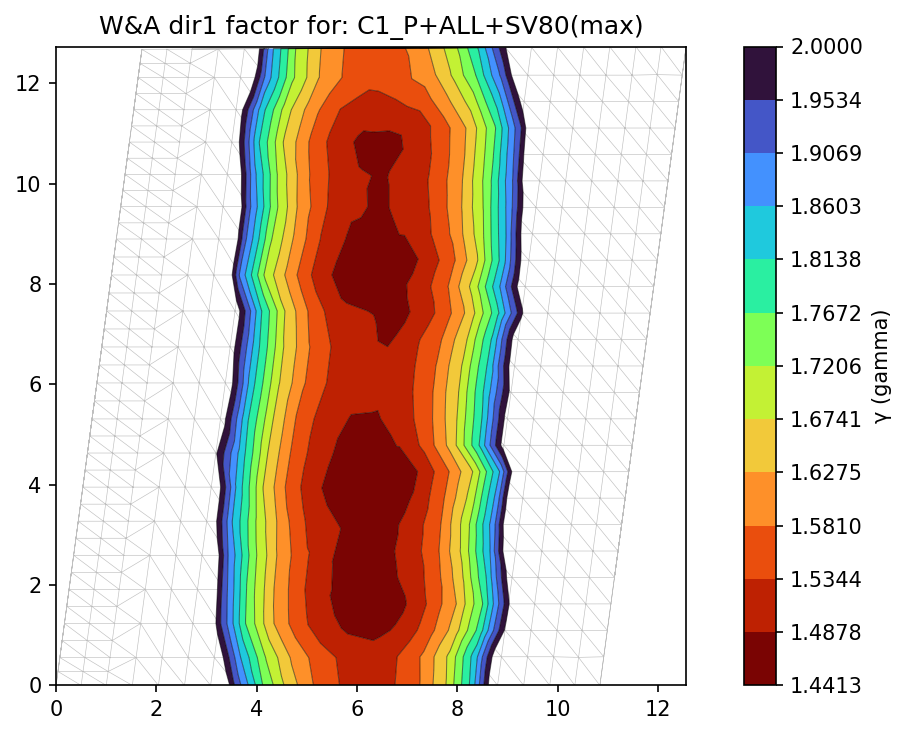

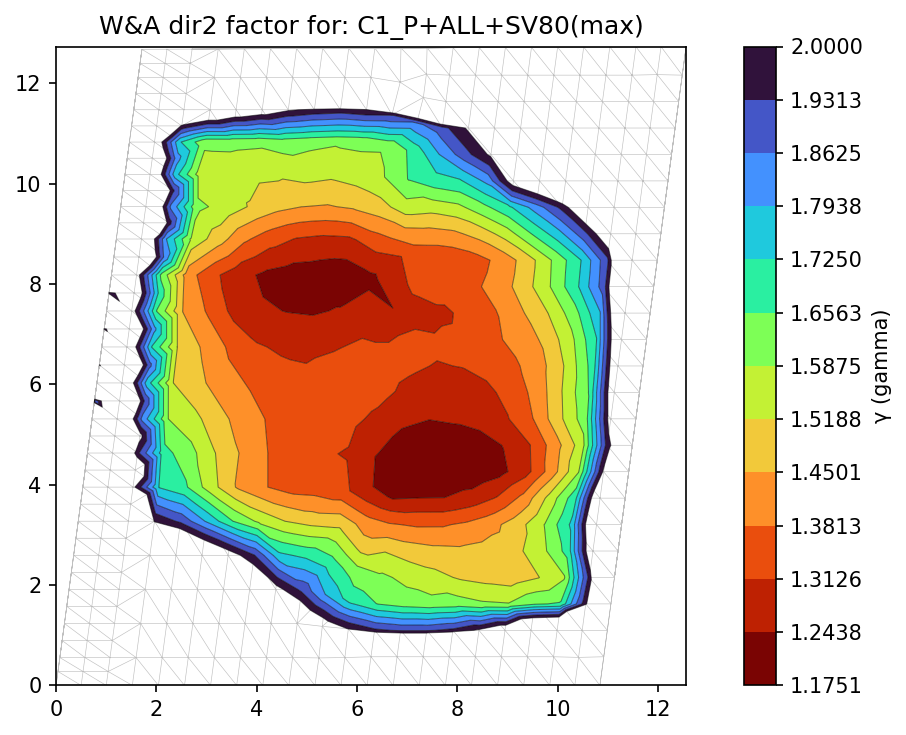

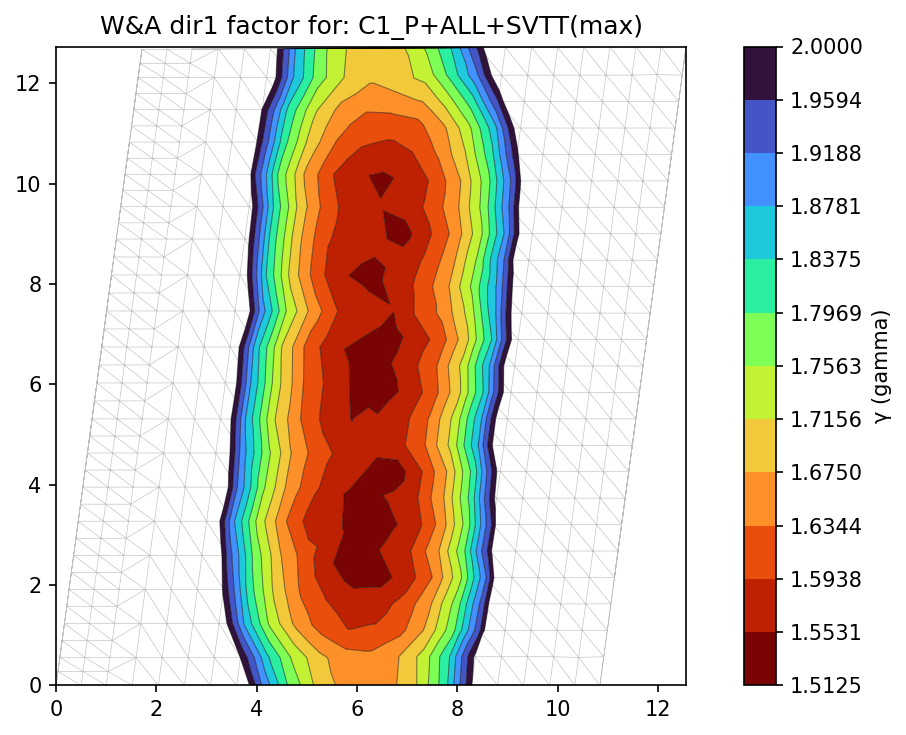

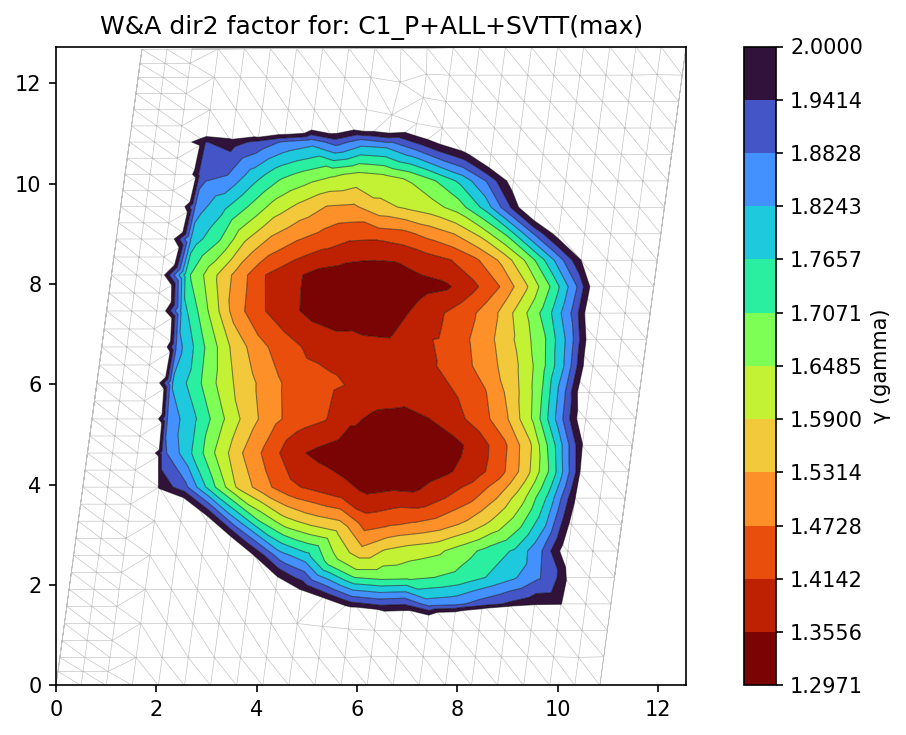

In [19]:
# PLOTTING
for i, load in enumerate(loads[1:]):
    mask = WA_results['Load'] == load
    x = WA_results[mask]['x'].to_numpy()
    y = WA_results[mask]['y'].to_numpy()
    z1 = WA_results[mask]['dir1'].to_numpy()
    z2 = WA_results[mask]['dir2'].to_numpy()
    plot1 = contour_plot(x, y, z1, cmax=2, title= 'W&A dir1 factor for: ' + load)
    plot2 = contour_plot(x, y, z2, cmax=2, title= 'W&A dir2 factor for: ' + load)

In [20]:
WA_summary = WA_results.groupby('Load')[['dir1', 'dir2']].min().round(3).reset_index()
WA_summary

,Load,dir1,dir2
0,C1_P,2.718,2.608
1,C1_P+ALL(max),1.689,1.399
2,C1_P+ALL+45HB(max),1.257,1.026
3,C1_P+ALL+SV100(max),1.346,1.065
4,C1_P+ALL+SV150(max),1.340,1.029
5,C1_P+ALL+SV196(max),1.289,0.967
6,C1_P+ALL+SV80(max),1.441,1.175
7,C1_P+ALL+SVTT(max),1.513,1.297


In [21]:
wb.sheets['W&A_results'].range('X2').value = WA_summary